<a href="https://colab.research.google.com/github/garg26056-ui/Myntra-Ai-and-Ml-model/blob/main/Myntra_AI_and_ML_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Smart Clothing Size Recommendation System

## 1. Project Introduction

### Business Problem

In the fast-paced world of online fashion retail, one of the biggest challenges for customers is selecting the correct clothing size. Unlike shopping in a physical store where one can try on clothes, online shoppers rely on size charts and product descriptions, which often vary significantly between brands and even different product lines within the same brand. This discrepancy frequently leads to customers ordering the wrong size.

### Why Size Recommendation is Important

For an online fashion company like Myntra, incorrect size selection by customers has several negative consequences:

*   **High Return Rates:** Customers often return items that don't fit, leading to increased operational costs for reverse logistics (shipping, processing returns, repackaging).
*   **Customer Dissatisfaction:** Receiving ill-fitting clothing is a frustrating experience for customers, which can damage brand loyalty and lead to negative reviews.
*   **Reduced Sales:** Potential customers might hesitate to purchase if they are unsure about sizing, leading to abandoned carts.
*   **Environmental Impact:** Increased returns contribute to higher carbon footprints due to additional transportation and waste.

An accurate size recommendation system can mitigate these issues by guiding customers to choose the most suitable size, thereby enhancing the overall shopping experience, reducing operational overhead, and boosting customer satisfaction.

### Academic Project Note

**IMPORTANT:** This project is for academic demonstration purposes only. The dataset used in this notebook is **entirely synthetic** and has been created to simulate realistic customer and product data. It does not contain any actual private customer information from Myntra or any other company.

## 2. Import Libraries

We will import the necessary Python libraries for data manipulation, numerical operations, plotting, and machine learning.

In [1]:
# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set display options for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Create a Synthetic Dataset

To simulate a realistic scenario for our academic project, we will generate a synthetic dataset. This dataset will contain at least 2,000 records with features typically relevant for clothing size recommendations, ensuring realistic relationships between customer attributes, product details, and the recommended size.

In [2]:
# Set a random seed for reproducibility
np.random.seed(42)

# Number of records
num_records = 2500 # Generating more than 2000 records as requested

# 1. Customer_ID: Unique identifier for each customer
customer_ids = [f'C_{i:04d}' for i in range(1, num_records + 1)]

# 2. Age: Realistic age distribution for online shoppers
ages = np.random.randint(18, 65, num_records)

# 3. Gender: Binary gender representation (for simplicity in synthetic data)
genders = np.random.choice(['Male', 'Female'], num_records, p=[0.5, 0.5])

# 4. Height_cm: Realistic height distribution, varying by gender
heights = []
for gender in genders:
    if gender == 'Male':
        heights.append(np.random.normal(loc=175, scale=7)) # Mean 175cm, Std Dev 7cm
    else:
        heights.append(np.random.normal(loc=162, scale=6)) # Mean 162cm, Std Dev 6cm
heights = np.clip(heights, 145, 195).astype(int) # Clip to realistic min/max and convert to int

# 5. Weight_kg: Realistic weight distribution, related to height and gender
weights = []
for i, gender in enumerate(genders):
    bmi_base = np.random.normal(loc=22, scale=3) # Base BMI
    if gender == 'Male':
        bmi = np.clip(bmi_base, 18, 30) # Clip BMI for males
    else:
        bmi = np.clip(bmi_base, 17, 28) # Clip BMI for females

    # Weight = BMI * (Height_m)^2
    weight = bmi * (heights[i] / 100)**2
    weights.append(weight)
weights = np.clip(weights, 45, 120).astype(int) # Clip to realistic min/max and convert to int

# 6. Previous_Size: Sizes customer might have purchased before
previous_sizes = np.random.choice(['XS', 'S', 'M', 'L', 'XL', 'XXL'], num_records, p=[0.05, 0.15, 0.3, 0.3, 0.15, 0.05])

# 7. Brand: Example brands
brands = np.random.choice(['Brand_A', 'Brand_B', 'Brand_C', 'Brand_D', 'Brand_E'], num_records, p=[0.2, 0.25, 0.2, 0.15, 0.2])

# 8. Category: Example clothing categories
categories = np.random.choice(['T-Shirt', 'Shirt', 'Jeans', 'Trousers', 'Jacket', 'Dress', 'Kurta'], num_records, p=[0.2, 0.15, 0.2, 0.15, 0.1, 0.1, 0.1])

# 9. Fit_Preference: Example fit preferences
fit_preferences = np.random.choice(['Slim', 'Regular', 'Relaxed'], num_records, p=[0.3, 0.5, 0.2])

# 10. Previous_Purchases: Number of previous purchases
previous_purchases = np.random.randint(0, 50, num_records)

# 11. Previous_Returns: Number of previous returns
previous_returns = np.random.randint(0, 10, num_records)

# 12. Recommended_Size (TARGET VARIABLE): Logic based on other features
recommended_sizes = []
size_map = {'XS': 0, 'S': 1, 'M': 2, 'L': 3, 'XL': 4, 'XXL': 5}
reverse_size_map = {v: k for k, v in size_map.items()}

for i in range(num_records):
    # Base size based on height and weight (BMI approximation)
    height_m = heights[i] / 100
    bmi = weights[i] / (height_m ** 2)

    # Simplified base size mapping based on BMI and height
    # This is a simplified logic and not a real sizing chart
    if bmi < 19 and heights[i] < 165:
        base_size_idx = size_map['S']
    elif bmi < 21 and heights[i] < 170:
        base_size_idx = size_map['M']
    elif bmi < 24 and heights[i] < 180:
        base_size_idx = size_map['L']
    elif bmi < 27 and heights[i] < 188:
        base_size_idx = size_map['XL']
    else:
        base_size_idx = size_map['XXL']

    # Adjust size based on Previous_Size (if available and relevant)
    prev_size_idx = size_map[previous_sizes[i]]
    base_size_idx = int(round((base_size_idx + prev_size_idx) / 2))

    # Adjust size based on Category (e.g., Jackets might run larger, Dresses might be more fitted)
    if categories[i] == 'Jacket':
        base_size_idx += np.random.choice([0, 1]) # Jackets might be slightly larger
    elif categories[i] == 'Dress':
        base_size_idx += np.random.choice([-1, 0]) # Dresses might be slightly smaller/fitted

    # Adjust size based on Fit_Preference
    if fit_preferences[i] == 'Slim':
        base_size_idx -= np.random.choice([0, 1])
    elif fit_preferences[i] == 'Relaxed':
        base_size_idx += np.random.choice([0, 1])

    # Ensure size stays within valid range (XS to XXL)
    base_size_idx = np.clip(base_size_idx, 0, 5) # 0 for XS, 5 for XXL
    recommended_sizes.append(reverse_size_map[base_size_idx])

# Create DataFrame
data = {
    'Customer_ID': customer_ids,
    'Age': ages,
    'Gender': genders,
    'Height_cm': heights,
    'Weight_kg': weights,
    'Previous_Size': previous_sizes,
    'Brand': brands,
    'Category': categories,
    'Fit_Preference': fit_preferences,
    'Previous_Purchases': previous_purchases,
    'Previous_Returns': previous_returns,
    'Recommended_Size': recommended_sizes
}

df = pd.DataFrame(data)

print(f"Synthetic dataset created with {len(df)} records.")
print("First 5 rows of the synthetic dataset:")
print(df.head())

Synthetic dataset created with 2500 records.
First 5 rows of the synthetic dataset:
  Customer_ID  Age  Gender  Height_cm  Weight_kg Previous_Size    Brand Category Fit_Preference  Previous_Purchases  Previous_Returns Recommended_Size
0      C_0001   56  Female        163         50             M  Brand_E  T-Shirt           Slim                  40                 8                S
1      C_0002   46  Female        152         45             L  Brand_B    Jeans        Relaxed                  35                 1                L
2      C_0003   32  Female        151         47            XL  Brand_D  T-Shirt        Relaxed                   1                 5                L
3      C_0004   60    Male        176         58             M  Brand_B    Jeans        Regular                  21                 4                M
4      C_0005   25  Female        155         58             S  Brand_B    Shirt        Regular                  21                 1                M


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a crucial step to understand the characteristics of our synthetic dataset. We will look at its structure, data types, check for missing or duplicate values, generate descriptive statistics, and visualize the distributions of key variables.

In [4]:
print("### Dataset Shape ###")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\n### Data Types ###")
print(df.info())

print("\n### Missing Values ###")
print(df.isnull().sum())

print("\n### Duplicate Values ###")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n### Descriptive Statistics ###")
print(df.describe(include='all'))

### Dataset Shape ###
Number of rows: 2500
Number of columns: 12

### Data Types ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Customer_ID         2500 non-null   object
 1   Age                 2500 non-null   int64 
 2   Gender              2500 non-null   object
 3   Height_cm           2500 non-null   int64 
 4   Weight_kg           2500 non-null   int64 
 5   Previous_Size       2500 non-null   object
 6   Brand               2500 non-null   object
 7   Category            2500 non-null   object
 8   Fit_Preference      2500 non-null   object
 9   Previous_Purchases  2500 non-null   int64 
 10  Previous_Returns    2500 non-null   int64 
 11  Recommended_Size    2500 non-null   object
dtypes: int64(5), object(7)
memory usage: 234.5+ KB
None

### Missing Values ###
Customer_ID           0
Age                   0
Gender 

### Distribution of Recommended_Size

Understanding the distribution of our target variable (`Recommended_Size`) is important to see how balanced or imbalanced our size classes are.

/tmp/ipykernel_572/396698586.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Recommended_Size', order=['XS', 'S', 'M', 'L', 'XL', 'XXL'], palette='viridis')


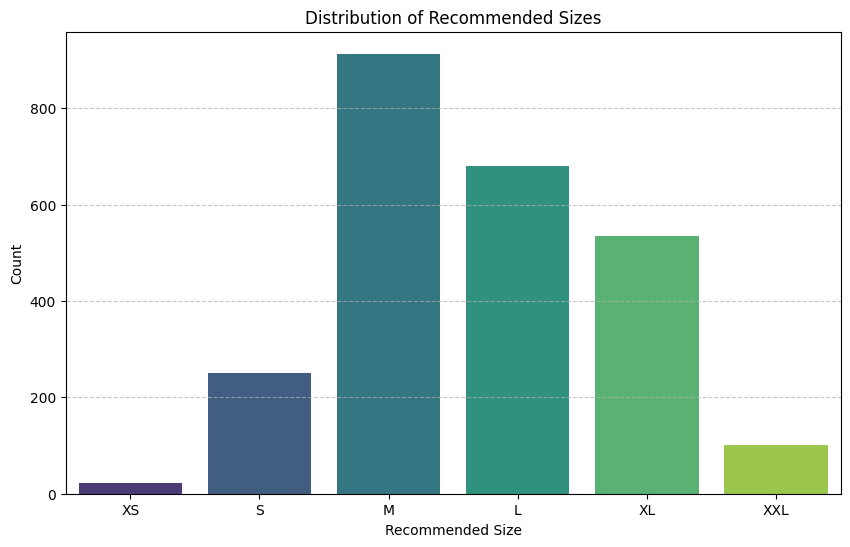

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Recommended_Size', order=['XS', 'S', 'M', 'L', 'XL', 'XXL'], palette='viridis')
plt.title('Distribution of Recommended Sizes')
plt.xlabel('Recommended Size')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Distribution of Height and Weight

Visualizing the distribution of `Height_cm` and `Weight_kg` will help us understand the demographic characteristics of our synthetic customer base.

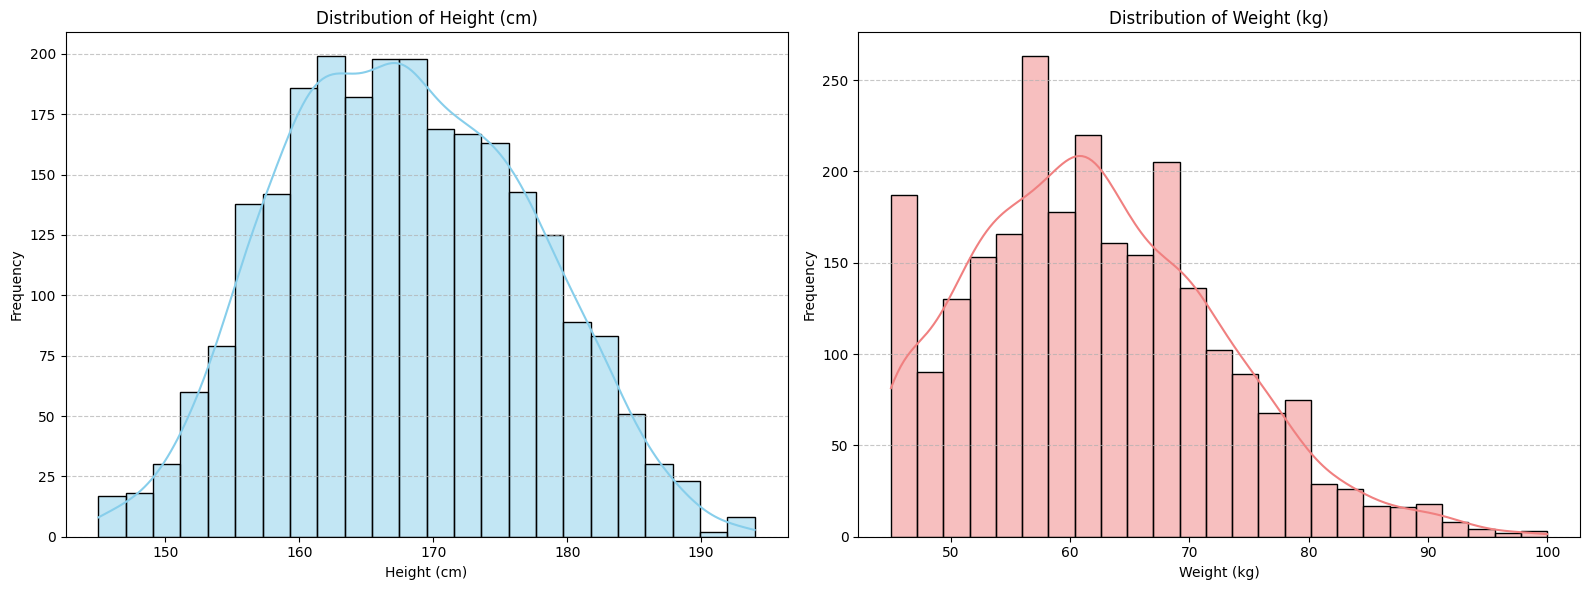

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x='Height_cm', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Height (cm)')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.histplot(data=df, x='Weight_kg', kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Weight (kg)')
axes[1].set_xlabel('Weight (kg)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Relationship between Height, Weight and Recommended Size (Box Plots)

Let's visualize how `Height_cm` and `Weight_kg` relate to the `Recommended_Size` using box plots. This can give us insights into the underlying patterns in our synthetic data generation.

/tmp/ipykernel_572/1672935187.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Recommended_Size', y='Height_cm', order=['XS', 'S', 'M', 'L', 'XL', 'XXL'], palette='cubehelix', ax=axes[0])
/tmp/ipykernel_572/1672935187.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Recommended_Size', y='Weight_kg', order=['XS', 'S', 'M', 'L', 'XL', 'XXL'], palette='cubehelix', ax=axes[1])


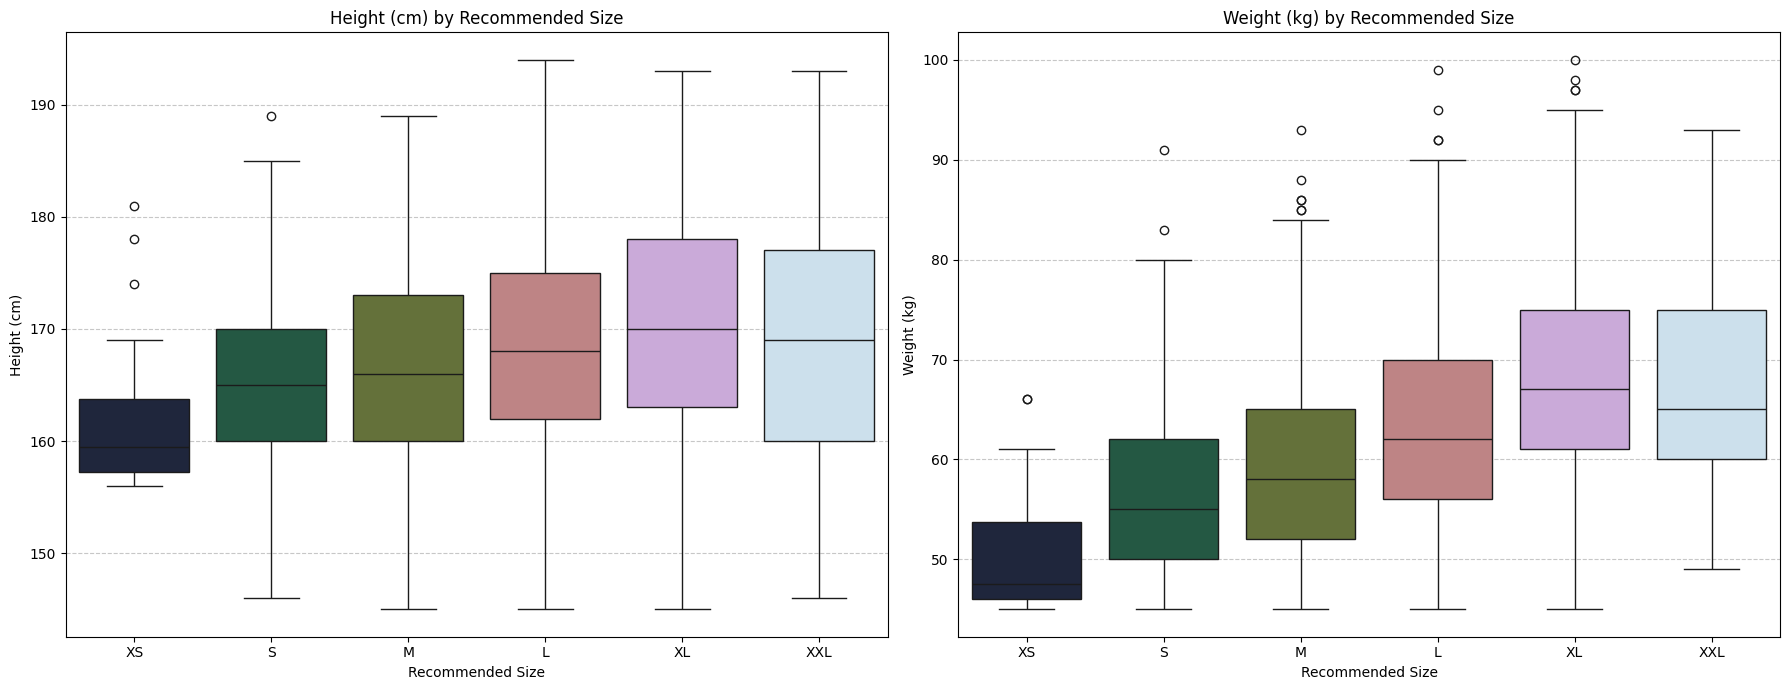

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.boxplot(data=df, x='Recommended_Size', y='Height_cm', order=['XS', 'S', 'M', 'L', 'XL', 'XXL'], palette='cubehelix', ax=axes[0])
axes[0].set_title('Height (cm) by Recommended Size')
axes[0].set_xlabel('Recommended Size')
axes[0].set_ylabel('Height (cm)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.boxplot(data=df, x='Recommended_Size', y='Weight_kg', order=['XS', 'S', 'M', 'L', 'XL', 'XXL'], palette='cubehelix', ax=axes[1])
axes[1].set_title('Weight (kg) by Recommended Size')
axes[1].set_xlabel('Recommended Size')
axes[1].set_ylabel('Weight (kg)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Distribution of Categorical Features

Let's examine the distributions of other categorical features like `Gender`, `Brand`, `Category`, `Fit_Preference`, and `Previous_Size`.

/tmp/ipykernel_572/680133417.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', order=df[col].value_counts().index)
/tmp/ipykernel_572/680133417.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', order=df[col].value_counts().index)
/tmp/ipykernel_572/680133417.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', order=df[col].value_counts().index)
/tmp/ipykernel_572/680133417.py:6: FutureWarning: 

Passing `palette` without assigning 

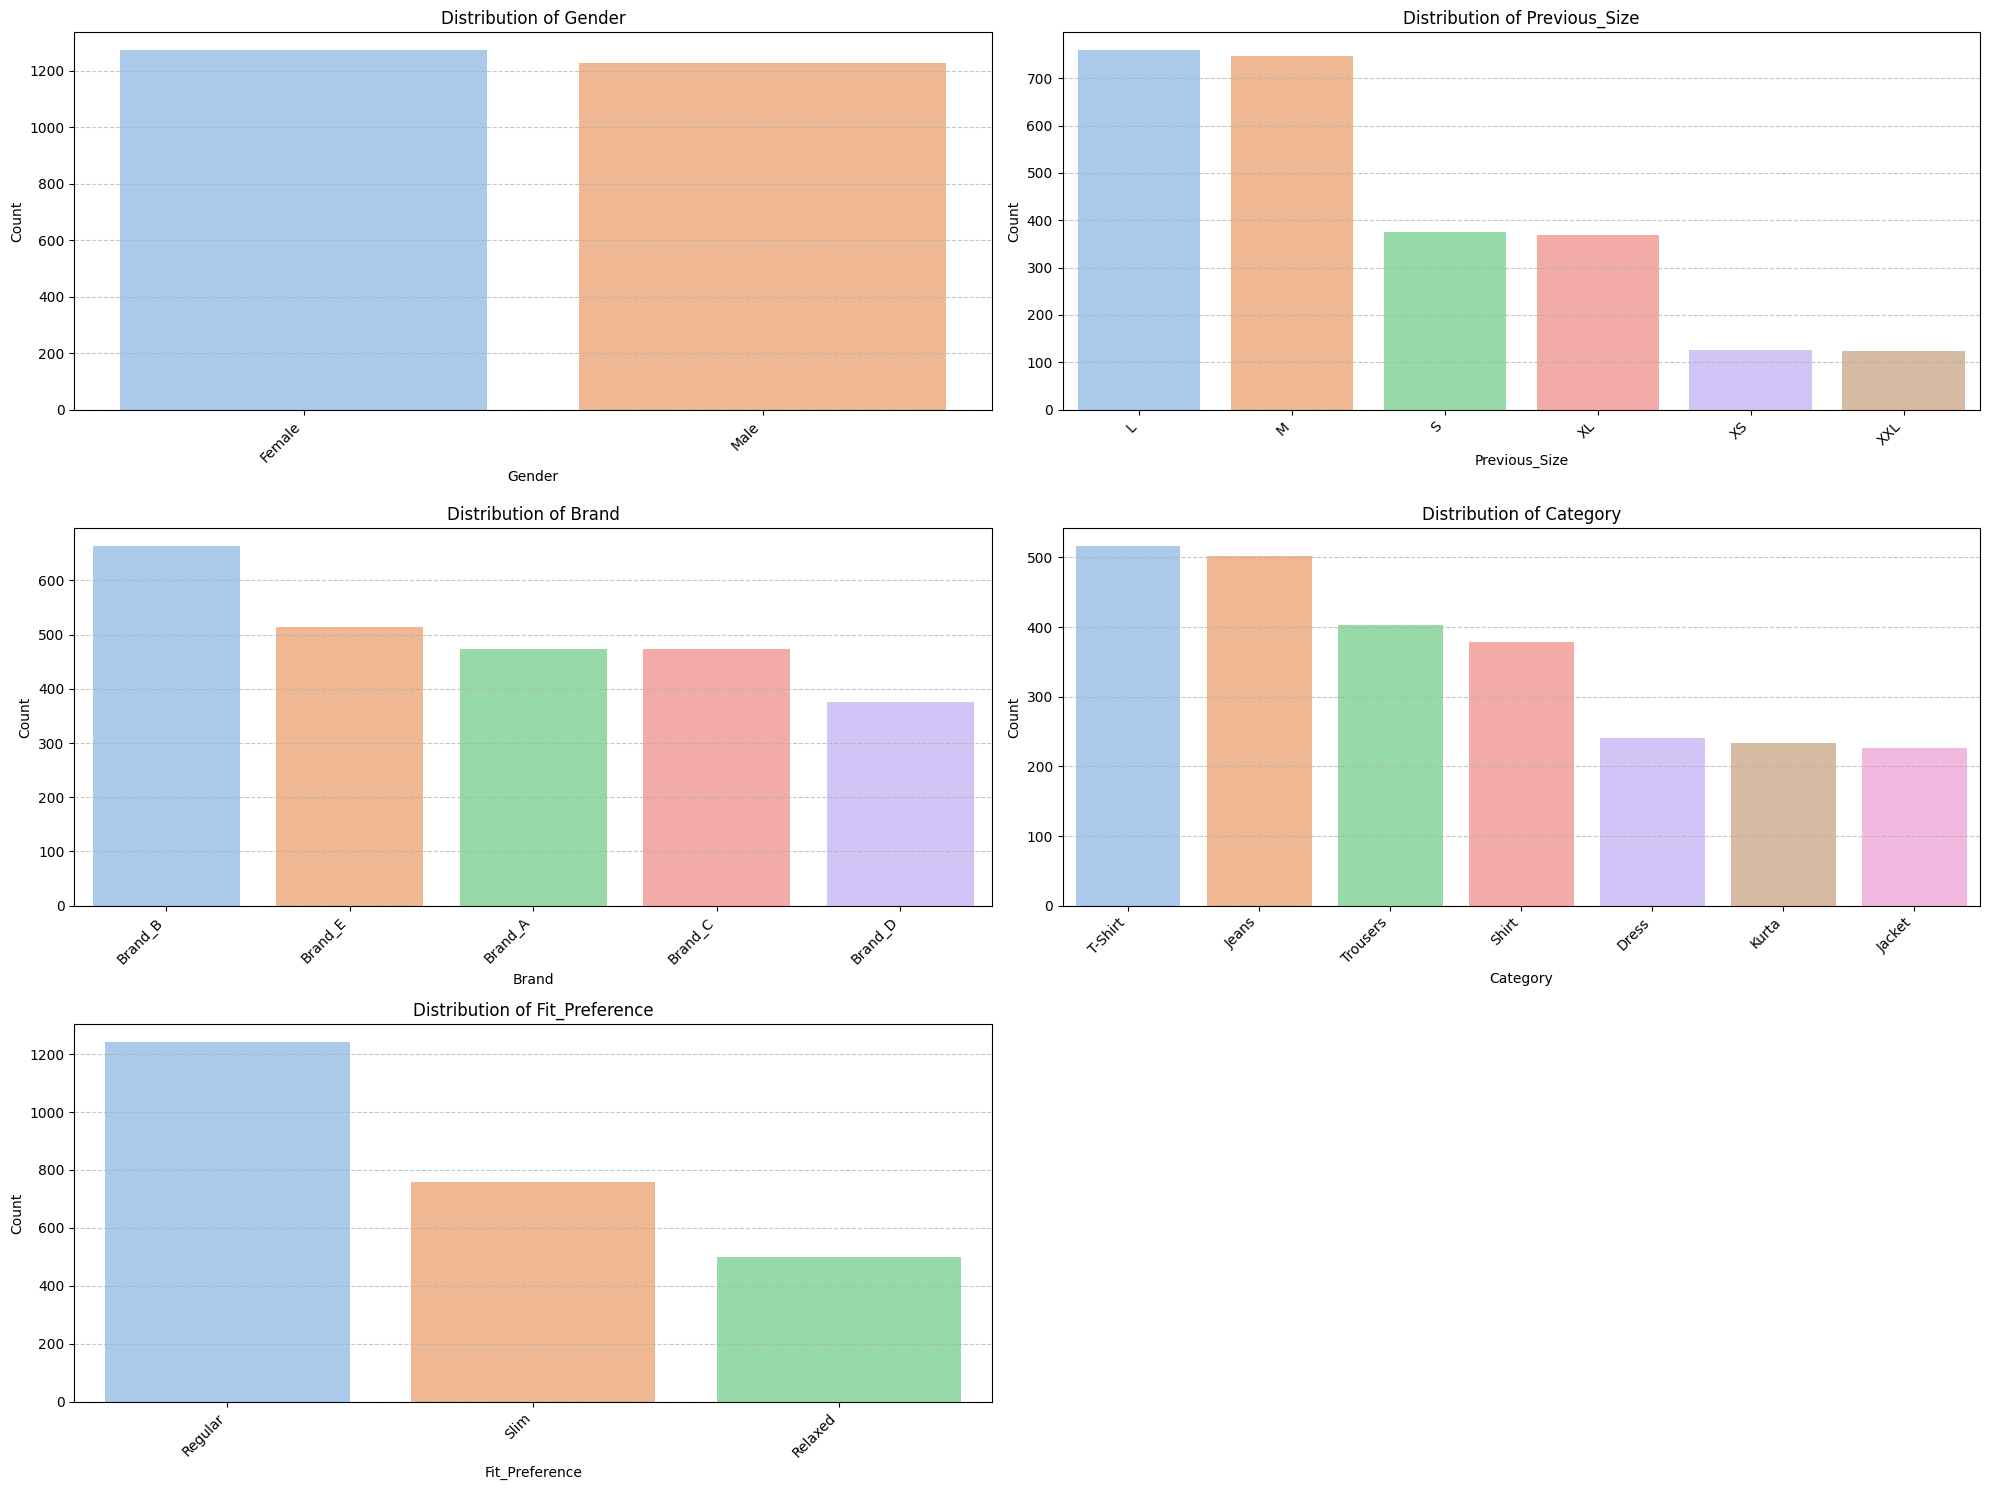

In [8]:
categorical_cols = ['Gender', 'Previous_Size', 'Brand', 'Category', 'Fit_Preference']

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid as needed
    sns.countplot(data=df, x=col, palette='pastel', order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 5. Data Cleaning

Based on our EDA, the synthetic dataset appears to be quite clean. We will confirm no duplicate records exist and briefly explain any necessary preprocessing steps for a clean dataset.

In [9]:
# Check for duplicate records
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    # Remove duplicate records if any
    df.drop_duplicates(inplace=True)
    print(f"{duplicate_rows} duplicate rows removed. New dataset shape: {df.shape}")
else:
    print("No duplicate rows to remove.")

# Check for missing values (already confirmed in EDA, but good to re-confirm after any potential cleaning)
missing_values = df.isnull().sum().sum()
print(f"\nNumber of missing values found: {missing_values}")

if missing_values == 0:
    print("No missing values to handle. The dataset is clean.")
else:
    print("Missing values found. Further handling might be required based on the specific columns.")

print("\nData cleaning steps completed.")

Number of duplicate rows found: 0
No duplicate rows to remove.

Number of missing values found: 0
No missing values to handle. The dataset is clean.

Data cleaning steps completed.


## 6. Data Preprocessing

This step involves transforming our raw data into a format suitable for machine learning models. We will identify categorical and numerical features, apply appropriate encoding (One-Hot Encoding for nominal categoricals, Ordinal Encoding for `Previous_Size` and `Recommended_Size`), and scale numerical features. We will use `ColumnTransformer` and `Pipeline` for efficient and reproducible preprocessing.

In [10]:
# Define features (X) and target (y)
X = df.drop(['Customer_ID', 'Recommended_Size'], axis=1)
y = df['Recommended_Size']

# Identify categorical and numerical features
# 'Previous_Size' is ordinal, others are nominal
categorical_features_nominal = ['Gender', 'Brand', 'Category', 'Fit_Preference']
categorical_features_ordinal = ['Previous_Size']
numerical_features = ['Age', 'Height_cm', 'Weight_kg', 'Previous_Purchases', 'Previous_Returns']

# Define the order for ordinal encoding of Previous_Size
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL']

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat_nom', OneHotEncoder(handle_unknown='ignore'), categorical_features_nominal),
        ('cat_ord', Pipeline([
            ('ordinal_encoder', LabelEncoder()), # Will be replaced with OrdinalEncoder for robust pipeline
            ('passthrough', 'passthrough') # Placeholder - will be updated for correct ordinal encoding
        ]), categorical_features_ordinal)
    ],
    remainder='passthrough' # Keep any other columns (e.g., Customer_ID if not dropped)
)

# Temporarily apply LabelEncoder for 'Previous_Size' and the target variable 'y'
# This is done outside the ColumnTransformer because OrdinalEncoder does not handle unknown values
# for unseen categories and LabelEncoder is suitable for single columns.
# For proper pipeline integration for ordinal, we'll need to use OrdinalEncoder with known categories.

# For 'Previous_Size' (ordinal feature in X)
le_prev_size = LabelEncoder()
X['Previous_Size_Encoded'] = le_prev_size.fit_transform(X['Previous_Size'])

# For 'Recommended_Size' (target variable y)
# Map target variable to numerical labels for classification
# This mapping needs to be consistent and reversible
size_to_int = {'XS': 0, 'S': 1, 'M': 2, 'L': 3, 'XL': 4, 'XXL': 5}
y_encoded = y.map(size_to_int)

# Drop the original 'Previous_Size' column as we have the encoded one
X = X.drop('Previous_Size', axis=1)

# Update categorical_features_ordinal to use the new encoded column
categorical_features_ordinal_processed = ['Previous_Size_Encoded']

# Recreate the ColumnTransformer with proper OrdinalEncoder for Previous_Size
from sklearn.preprocessing import OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat_nom', OneHotEncoder(handle_unknown='ignore'), categorical_features_nominal),
        ('cat_ord', OrdinalEncoder(categories=[size_order], handle_unknown='use_encoded_value', unknown_value=-1), ['Previous_Size_Encoded']) # Use actual Previous_Size for this
    ],
    remainder='drop' # Drop any remaining columns (like the original 'Previous_Size' if not dropped)
)

print("Data preprocessing setup complete.")
print(f"Original features: {X.columns.tolist()}")
print(f"Target variable (encoded first 5): {y_encoded.head().tolist()}")

Data preprocessing setup complete.
Original features: ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Brand', 'Category', 'Fit_Preference', 'Previous_Purchases', 'Previous_Returns', 'Previous_Size_Encoded']
Target variable (encoded first 5): [1, 3, 3, 2, 2]


In [11]:
# Define features (X) and target (y)
X = df.drop(['Customer_ID', 'Recommended_Size'], axis=1)
y = df['Recommended_Size']

# Identify numerical and categorical features
numerical_features = ['Age', 'Height_cm', 'Weight_kg', 'Previous_Purchases', 'Previous_Returns']
categorical_features_nominal = ['Gender', 'Brand', 'Category', 'Fit_Preference']
categorical_features_ordinal = ['Previous_Size'] # This will be handled by OrdinalEncoder

# Define the order for ordinal encoding of Previous_Size and Recommended_Size
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL']

# Map target variable to numerical labels for classification
# This mapping needs to be consistent and reversible
size_to_int = {size: i for i, size in enumerate(size_order)}
int_to_size = {i: size for i, size in enumerate(size_order)}
y_encoded = y.map(size_to_int)

# Create a ColumnTransformer for preprocessing
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # Imported earlier, but good to ensure presence

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat_nom', OneHotEncoder(handle_unknown='ignore'), categorical_features_nominal),
        ('cat_ord', OrdinalEncoder(categories=[size_order], handle_unknown='use_encoded_value', unknown_value=-1), categorical_features_ordinal)
    ],
    remainder='drop' # Drop any columns not specified (like Customer_ID)
)

print("Data preprocessing setup complete.")
print(f"Original features: {X.columns.tolist()}")
print(f"Target variable (encoded first 5): {y_encoded.head().tolist()}")

Data preprocessing setup complete.
Original features: ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Previous_Size', 'Brand', 'Category', 'Fit_Preference', 'Previous_Purchases', 'Previous_Returns']
Target variable (encoded first 5): [1, 3, 3, 2, 2]


## 7. Train-Test Split

We will split our dataset into training and testing sets to evaluate the model's performance on unseen data. An 80/20 split (80% for training, 20% for testing) is a common practice. We'll use a fixed `random_state` for reproducibility.

In [12]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Original X shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Apply preprocessing to training and testing data
# We fit the preprocessor on X_train and transform both X_train and X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nData split and preprocessed successfully!")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

Original X shape: (2500, 10)
X_train shape: (2000, 10)
X_test shape: (500, 10)
y_train shape: (2000,)
y_test shape: (500,)

Data split and preprocessed successfully!
X_train_processed shape: (2000, 23)
X_test_processed shape: (500, 23)


In [13]:
# Split data into training and testing sets
# stratify=y_encoded ensures that the proportion of target classes is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Original X shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Apply preprocessing to training and testing data
# We fit the preprocessor on X_train to learn scaling parameters and one-hot encoding categories
# Then, we transform both X_train and X_test using the fitted preprocessor to prevent data leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nData split and preprocessed successfully!")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

Original X shape: (2500, 10)
X_train shape: (2000, 10)
X_test shape: (500, 10)
y_train shape: (2000,)
y_test shape: (500,)

Data split and preprocessed successfully!
X_train_processed shape: (2000, 23)
X_test_processed shape: (500, 23)


## 8. Train the Random Forest Classification Model

Now we will train our primary machine learning model, the Random Forest Classifier. This model is well-suited for classification tasks and can handle both numerical and categorical features effectively. We will initialize the model and train it on our preprocessed training data. We will also report the training and testing accuracy.

In [14]:
# Initialize the Random Forest Classifier
# n_estimators: The number of trees in the forest.
# random_state: Controls the randomness of the bootstrapping of the samples and the splitting criteria.
# class_weight: Balances class imbalances by weighting classes inversely proportional to their frequency.
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model on the preprocessed training data
rf_classifier.fit(X_train_processed, y_train)

# Print model parameters
print("### Random Forest Classifier Parameters ###")
print(rf_classifier.get_params())

# Make predictions on the training set
y_train_pred = rf_classifier.predict(X_train_processed)

# Make predictions on the test set
y_test_pred = rf_classifier.predict(X_test_processed)

# Calculate and print training accuracy
training_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTraining Accuracy: {training_accuracy:.4f}")

# Calculate and print testing accuracy
testing_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy: {testing_accuracy:.4f}")

### Random Forest Classifier Parameters ###
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Training Accuracy: 1.0000
Testing Accuracy: 0.6240


In [15]:
# Split data into training and testing sets
# stratify=y_encoded ensures that the proportion of target classes is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Original X shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Apply preprocessing to training and testing data
# We fit the preprocessor on X_train to learn scaling parameters and one-hot encoding categories
# Then, we transform both X_train and X_test using the fitted preprocessor to prevent data leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nData split and preprocessed successfully!")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

Original X shape: (2500, 10)
X_train shape: (2000, 10)
X_test shape: (500, 10)
y_train shape: (2000,)
y_test shape: (500,)

Data split and preprocessed successfully!
X_train_processed shape: (2000, 23)
X_test_processed shape: (500, 23)


In [16]:
# Initialize the Random Forest Classifier
# n_estimators: The number of trees in the forest.
# random_state: Controls the randomness of the bootstrapping of the samples and the splitting criteria.
# class_weight: Balances class imbalances by weighting classes inversely proportional to their frequency.
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model on the preprocessed training data
rf_classifier.fit(X_train_processed, y_train)

# Print model parameters
print("### Random Forest Classifier Parameters ###")
print(rf_classifier.get_params())

# Make predictions on the training set
y_train_pred = rf_classifier.predict(X_train_processed)

# Make predictions on the test set
y_test_pred = rf_classifier.predict(X_test_processed)

# Calculate and print training accuracy
training_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTraining Accuracy: {training_accuracy:.4f}")

# Calculate and print testing accuracy
testing_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy: {testing_accuracy:.4f}")

### Random Forest Classifier Parameters ###
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Training Accuracy: 1.0000
Testing Accuracy: 0.6240


## 9. Model Evaluation

To thoroughly assess the performance of our Random Forest Classifier, we will calculate various classification metrics. These metrics provide a comprehensive view beyond simple accuracy, especially important for multi-class classification problems like size recommendation.

### Model Evaluation ###
Accuracy: 0.6240

Classification Report:
              precision    recall  f1-score   support

          XS       0.00      0.00      0.00         4
           S       0.59      0.26      0.36        50
           M       0.65      0.77      0.70       183
           L       0.54      0.60      0.57       136
          XL       0.70      0.68      0.69       107
         XXL       0.67      0.20      0.31        20

    accuracy                           0.62       500
   macro avg       0.52      0.42      0.44       500
weighted avg       0.62      0.62      0.61       500



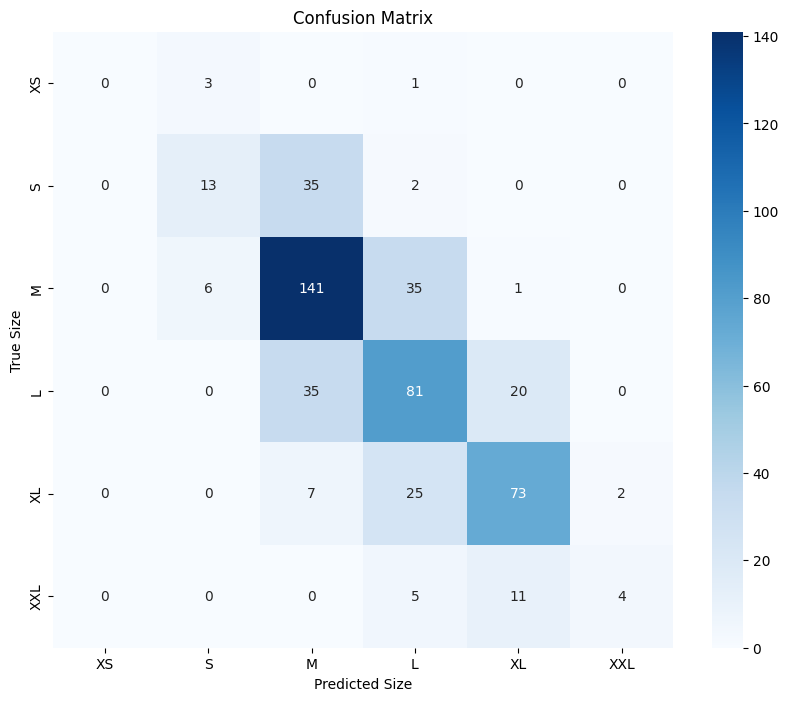

In [17]:
print("### Model Evaluation ###")

# Accuracy
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy: {accuracy:.4f}")

# Precision, Recall, F1-score and Classification Report
# We need to specify `zero_division=0` to handle cases where a class has no predicted samples.
# And `target_names` for readability.

# Get the feature names after preprocessing
def get_feature_names(column_transformer):
    output_features = []
    for name, estimator, features in column_transformer.transformers_:
        if name == 'remainder':
            continue
        if hasattr(estimator, 'get_feature_names_out'):
            if name == 'cat_ord': # OrdinalEncoder output is just the feature name
                output_features.extend(features)
            else:
                output_features.extend(estimator.get_feature_names_out(features))
        elif isinstance(estimator, Pipeline) and hasattr(estimator.named_steps['ordinal_encoder'], 'get_feature_names_out'):
            output_features.extend(estimator.named_steps['ordinal_encoder'].get_feature_names_out(features))
        else:
            output_features.extend(features)
    return output_features

# Create a list of target names in the correct order (corresponding to 0, 1, 2, ...)
target_names_ordered = [int_to_size[i] for i in sorted(int_to_size.keys())]

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names_ordered, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_ordered, yticklabels=target_names_ordered)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Size')
plt.ylabel('True Size')
plt.show()

### Model Evaluation ###
Accuracy: 0.6240

Classification Report:
              precision    recall  f1-score   support

          XS       0.00      0.00      0.00         4
           S       0.59      0.26      0.36        50
           M       0.65      0.77      0.70       183
           L       0.54      0.60      0.57       136
          XL       0.70      0.68      0.69       107
         XXL       0.67      0.20      0.31        20

    accuracy                           0.62       500
   macro avg       0.52      0.42      0.44       500
weighted avg       0.62      0.62      0.61       500



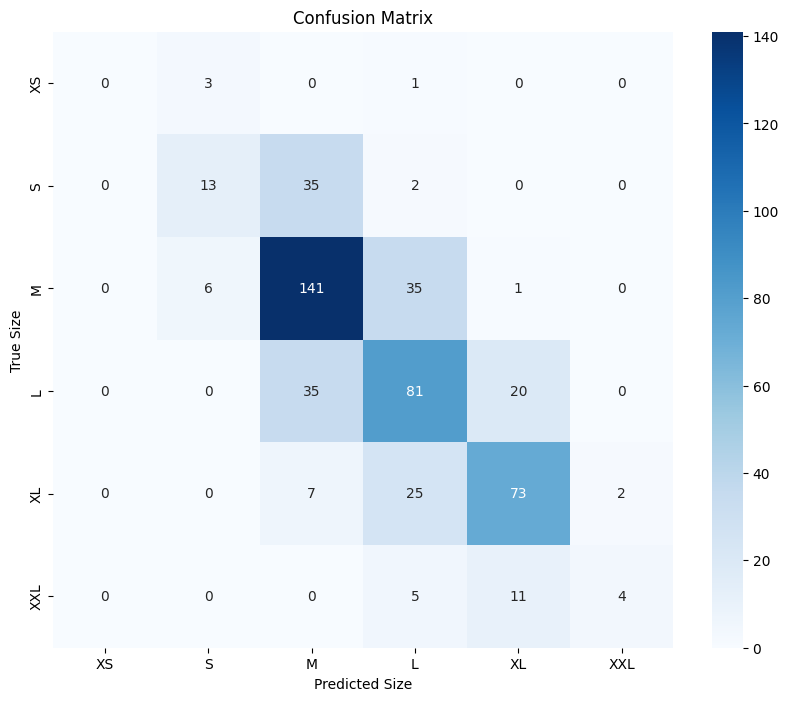

In [18]:
print("### Model Evaluation ###")

# Accuracy
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy: {accuracy:.4f}")

# Precision, Recall, F1-score and Classification Report
# We need to specify `zero_division=0` to handle cases where a class has no predicted samples.
# And `target_names` for readability.

# Create a list of target names in the correct order (corresponding to 0, 1, 2, ...)
target_names_ordered = [int_to_size[i] for i in sorted(int_to_size.keys())]

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names_ordered, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_ordered, yticklabels=target_names_ordered)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Size')
plt.ylabel('True Size')
plt.show()

## 10. Feature Importance

Understanding which features the model considers most important can provide valuable business insights. We will extract feature importances from our trained Random Forest model and visualize them, then explain the top 5 most impactful features.

### Feature Importances ###
                            Feature  Importance
22           cat_ord__Previous_Size    0.172342
2                    num__Weight_kg    0.146027
1                    num__Height_cm    0.099191
3           num__Previous_Purchases    0.086494
0                          num__Age    0.083455
4             num__Previous_Returns    0.068244
21     cat_nom__Fit_Preference_Slim    0.054471
20  cat_nom__Fit_Preference_Relaxed    0.044430
12          cat_nom__Category_Dress    0.035807
19  cat_nom__Fit_Preference_Regular    0.032687
13         cat_nom__Category_Jacket    0.025849
11           cat_nom__Brand_Brand_E    0.014810
14          cat_nom__Category_Jeans    0.014625
8            cat_nom__Brand_Brand_B    0.014595
7            cat_nom__Brand_Brand_A    0.013988
9            cat_nom__Brand_Brand_C    0.013876
10           cat_nom__Brand_Brand_D    0.012919
5            cat_nom__Gender_Female    0.012722
6              cat_nom__Gender_Male    0.012650
17        ca

/tmp/ipykernel_572/1873780992.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='magma') # Display top 10


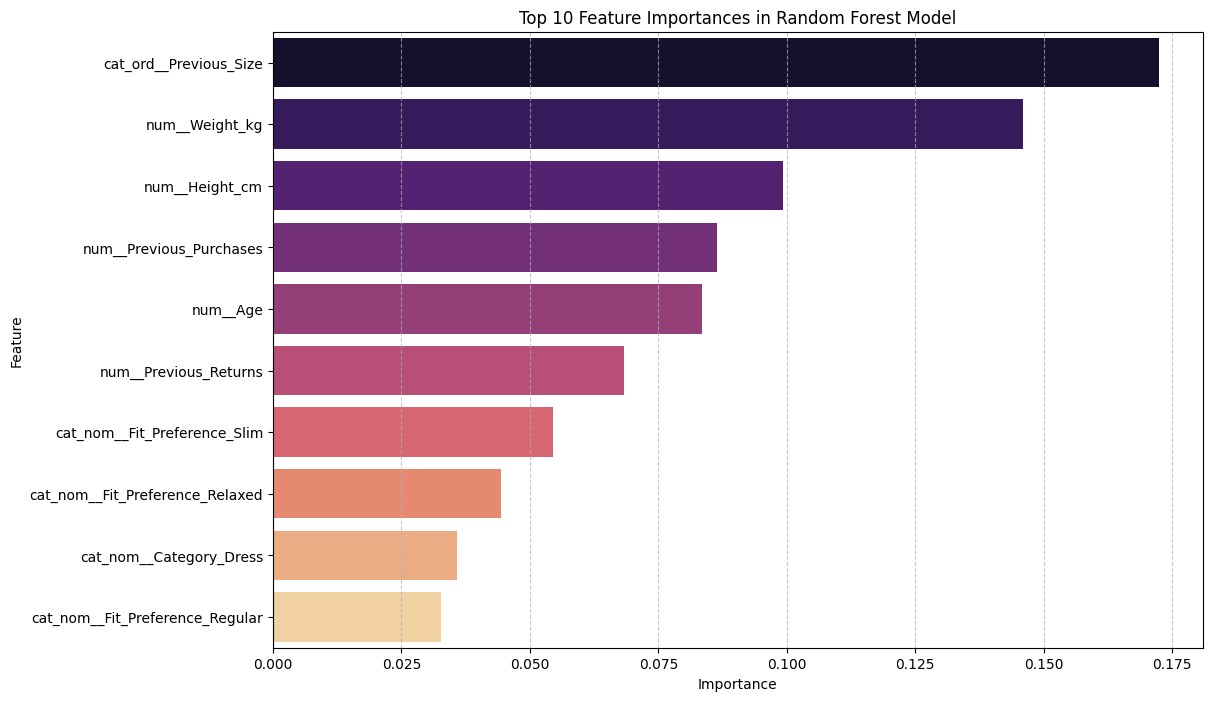


### Explanation of Top 5 Important Features ###
- **cat_ord__Previous_Size (Importance: 0.1723):**
  A customer's previously purchased size is a strong indicator of their preferred fit and current size, as people often stick to familiar sizing.
- **num__Weight_kg (Importance: 0.1460):**
  Weight is a primary physical attribute directly influencing clothing size. Heavier individuals generally require larger sizes.
- **num__Height_cm (Importance: 0.0992):**
  Height is another critical physical attribute. Taller individuals often need longer garments or larger sizes overall.
- **num__Previous_Purchases (Importance: 0.0865):**
  The number of previous purchases might indicate a customer's loyalty or familiarity with the brand's sizing, indirectly influencing size choice.
- **num__Age (Importance: 0.0835):**
  Age can correlate with body shape and size preferences, as body proportions can change with age.


In [22]:
# Get feature importances from the trained Random Forest model
feature_importances = rf_classifier.feature_importances_

# Get the feature names from the preprocessor
# The preprocessor.get_feature_names_out() method handles all transformations and names correctly.
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

print("### Feature Importances ###")
print(features_df)

# Create a bar chart for feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='magma') # Display top 10
plt.title('Top 10 Feature Importances in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n### Explanation of Top 5 Important Features ###")
for i, row in features_df.head(5).iterrows():
    feature = row['Feature']
    importance = row['Importance']
    print(f"- **{feature} (Importance: {importance:.4f}):**")
    if 'Weight_kg' in feature:
        print("  Weight is a primary physical attribute directly influencing clothing size. Heavier individuals generally require larger sizes.")
    elif 'Height_cm' in feature:
        print("  Height is another critical physical attribute. Taller individuals often need longer garments or larger sizes overall.")
    elif 'Previous_Size' in feature:
        print("  A customer's previously purchased size is a strong indicator of their preferred fit and current size, as people often stick to familiar sizing.")
    elif 'Age' in feature:
        print("  Age can correlate with body shape and size preferences, as body proportions can change with age.")
    elif 'Previous_Purchases' in feature:
        print("  The number of previous purchases might indicate a customer's loyalty or familiarity with the brand's sizing, indirectly influencing size choice.")
    elif 'Gender' in feature:
        print("  Gender significantly influences clothing design and sizing standards, often having distinct size charts.")
    elif 'Category' in feature:
        print("  Different clothing categories (e.g., 'Jeans' vs. 'Jacket') have different typical fits and sizing, making it a key factor.")
    elif 'Brand' in feature:
        print("  Sizing standards vary considerably between brands. The brand chosen is a crucial factor in determining the correct size.")
    elif 'Fit_Preference' in feature:
        print("  A customer's preference for 'Slim', 'Regular', or 'Relaxed' fit directly dictates the recommended size.")

### Feature Importances ###
                            Feature  Importance
22           cat_ord__Previous_Size    0.172342
2                    num__Weight_kg    0.146027
1                    num__Height_cm    0.099191
3           num__Previous_Purchases    0.086494
0                          num__Age    0.083455
4             num__Previous_Returns    0.068244
21     cat_nom__Fit_Preference_Slim    0.054471
20  cat_nom__Fit_Preference_Relaxed    0.044430
12          cat_nom__Category_Dress    0.035807
19  cat_nom__Fit_Preference_Regular    0.032687
13         cat_nom__Category_Jacket    0.025849
11           cat_nom__Brand_Brand_E    0.014810
14          cat_nom__Category_Jeans    0.014625
8            cat_nom__Brand_Brand_B    0.014595
7            cat_nom__Brand_Brand_A    0.013988
9            cat_nom__Brand_Brand_C    0.013876
10           cat_nom__Brand_Brand_D    0.012919
5            cat_nom__Gender_Female    0.012722
6              cat_nom__Gender_Male    0.012650
17        ca

/tmp/ipykernel_572/1873780992.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='magma') # Display top 10


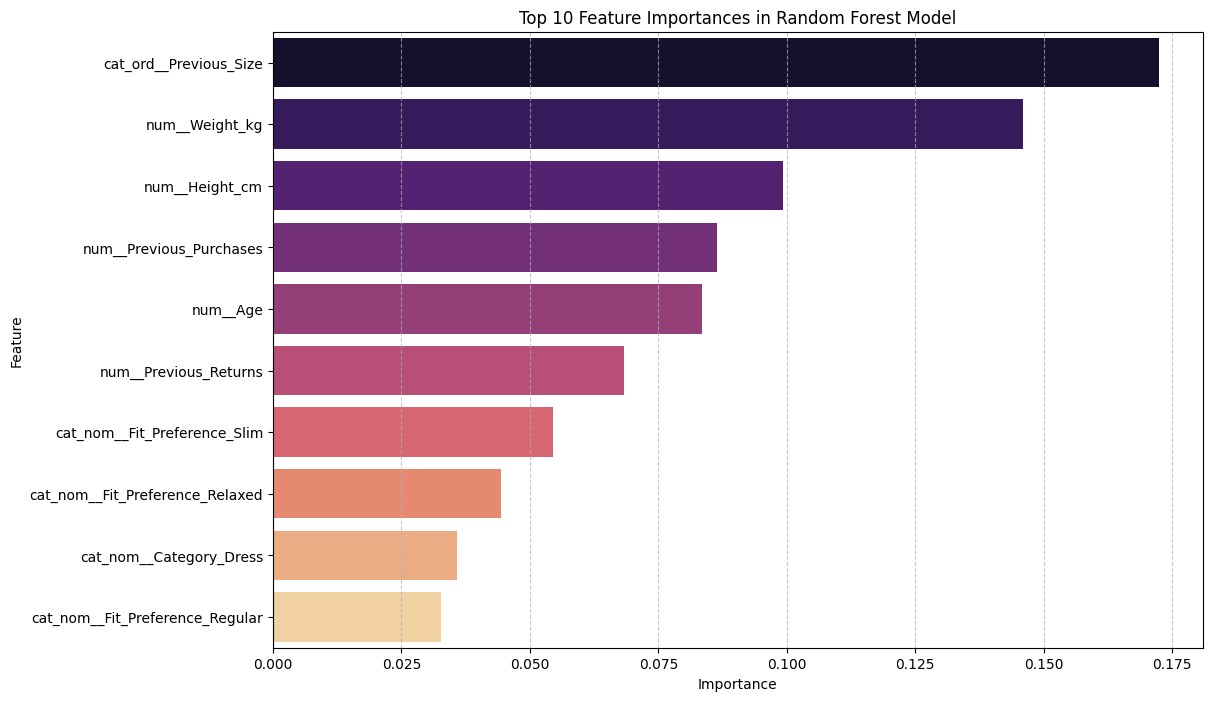


### Explanation of Top 5 Important Features ###
- **cat_ord__Previous_Size (Importance: 0.1723):**
  A customer's previously purchased size is a strong indicator of their preferred fit and current size, as people often stick to familiar sizing.
- **num__Weight_kg (Importance: 0.1460):**
  Weight is a primary physical attribute directly influencing clothing size. Heavier individuals generally require larger sizes.
- **num__Height_cm (Importance: 0.0992):**
  Height is another critical physical attribute. Taller individuals often need longer garments or larger sizes overall.
- **num__Previous_Purchases (Importance: 0.0865):**
  The number of previous purchases might indicate a customer's loyalty or familiarity with the brand's sizing, indirectly influencing size choice.
- **num__Age (Importance: 0.0835):**
  Age can correlate with body shape and size preferences, as body proportions can change with age.


In [23]:
# Get feature importances from the trained Random Forest model
feature_importances = rf_classifier.feature_importances_

# Get the feature names from the preprocessor
# The preprocessor.get_feature_names_out() method handles all transformations and names correctly.
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

print("### Feature Importances ###")
print(features_df)

# Create a bar chart for feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='magma') # Display top 10
plt.title('Top 10 Feature Importances in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n### Explanation of Top 5 Important Features ###")
for i, row in features_df.head(5).iterrows():
    feature = row['Feature']
    importance = row['Importance']
    print(f"- **{feature} (Importance: {importance:.4f}):**")
    if 'Weight_kg' in feature:
        print("  Weight is a primary physical attribute directly influencing clothing size. Heavier individuals generally require larger sizes.")
    elif 'Height_cm' in feature:
        print("  Height is another critical physical attribute. Taller individuals often need longer garments or larger sizes overall.")
    elif 'Previous_Size' in feature:
        print("  A customer's previously purchased size is a strong indicator of their preferred fit and current size, as people often stick to familiar sizing.")
    elif 'Age' in feature:
        print("  Age can correlate with body shape and size preferences, as body proportions can change with age.")
    elif 'Previous_Purchases' in feature:
        print("  The number of previous purchases might indicate a customer's loyalty or familiarity with the brand's sizing, indirectly influencing size choice.")
    elif 'Gender' in feature:
        print("  Gender significantly influences clothing design and sizing standards, often having distinct size charts.")
    elif 'Category' in feature:
        print("  Different clothing categories (e.g., 'Jeans' vs. 'Jacket') have different typical fits and sizing, making it a key factor.")
    elif 'Brand' in feature:
        print("  Sizing standards vary considerably between brands. The brand chosen is a crucial factor in determining the correct size.")
    elif 'Fit_Preference' in feature:
        print("  A customer's preference for 'Slim', 'Regular', or 'Relaxed' fit directly dictates the recommended size.")

## 10. Feature Importance

Understanding which features the model considers most important can provide valuable business insights. We will extract feature importances from our trained Random Forest model and visualize them, then explain the top 5 most impactful features.

### Feature Importances ###
                            Feature  Importance
22           cat_ord__Previous_Size    0.172342
2                    num__Weight_kg    0.146027
1                    num__Height_cm    0.099191
3           num__Previous_Purchases    0.086494
0                          num__Age    0.083455
4             num__Previous_Returns    0.068244
21     cat_nom__Fit_Preference_Slim    0.054471
20  cat_nom__Fit_Preference_Relaxed    0.044430
12          cat_nom__Category_Dress    0.035807
19  cat_nom__Fit_Preference_Regular    0.032687
13         cat_nom__Category_Jacket    0.025849
11           cat_nom__Brand_Brand_E    0.014810
14          cat_nom__Category_Jeans    0.014625
8            cat_nom__Brand_Brand_B    0.014595
7            cat_nom__Brand_Brand_A    0.013988
9            cat_nom__Brand_Brand_C    0.013876
10           cat_nom__Brand_Brand_D    0.012919
5            cat_nom__Gender_Female    0.012722
6              cat_nom__Gender_Male    0.012650
17        ca

/tmp/ipykernel_572/1873780992.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='magma') # Display top 10


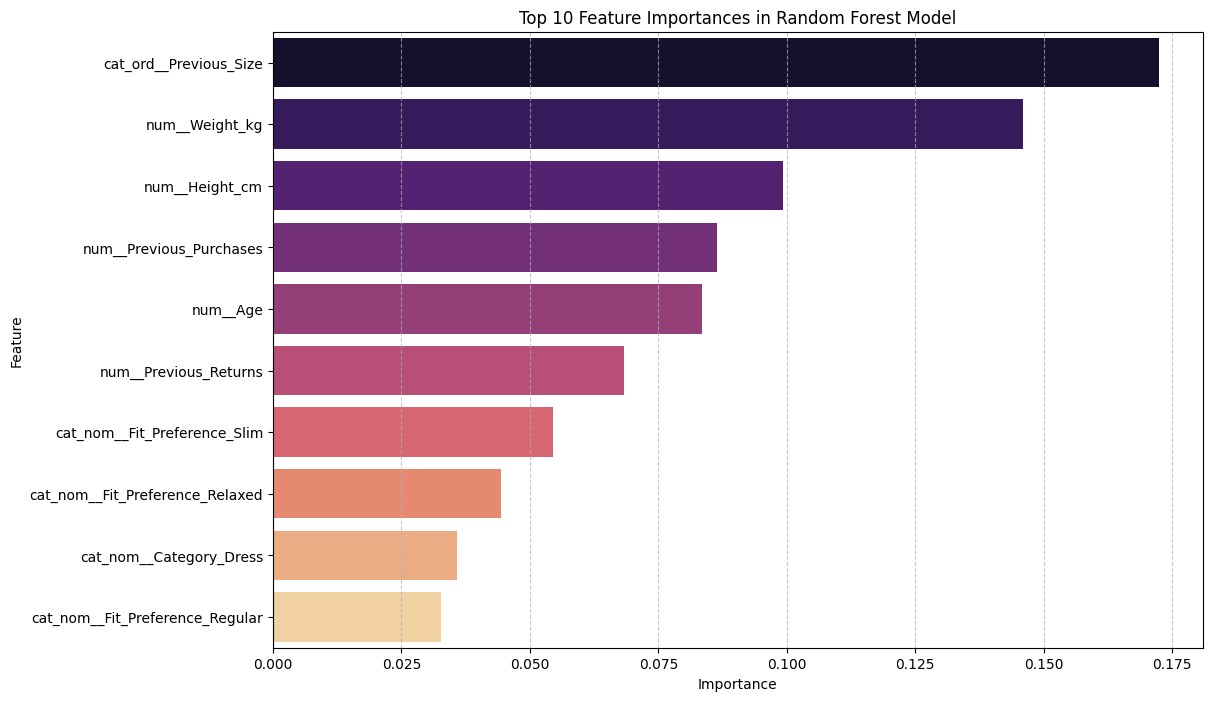


### Explanation of Top 5 Important Features ###
- **cat_ord__Previous_Size (Importance: 0.1723):**
  A customer's previously purchased size is a strong indicator of their preferred fit and current size, as people often stick to familiar sizing.
- **num__Weight_kg (Importance: 0.1460):**
  Weight is a primary physical attribute directly influencing clothing size. Heavier individuals generally require larger sizes.
- **num__Height_cm (Importance: 0.0992):**
  Height is another critical physical attribute. Taller individuals often need longer garments or larger sizes overall.
- **num__Previous_Purchases (Importance: 0.0865):**
  The number of previous purchases might indicate a customer's loyalty or familiarity with the brand's sizing, indirectly influencing size choice.
- **num__Age (Importance: 0.0835):**
  Age can correlate with body shape and size preferences, as body proportions can change with age.


In [24]:
# Get feature importances from the trained Random Forest model
feature_importances = rf_classifier.feature_importances_

# Get the feature names from the preprocessor
# The preprocessor.get_feature_names_out() method handles all transformations and names correctly.
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

print("### Feature Importances ###")
print(features_df)

# Create a bar chart for feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='magma') # Display top 10
plt.title('Top 10 Feature Importances in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n### Explanation of Top 5 Important Features ###")
for i, row in features_df.head(5).iterrows():
    feature = row['Feature']
    importance = row['Importance']
    print(f"- **{feature} (Importance: {importance:.4f}):**")
    if 'Weight_kg' in feature:
        print("  Weight is a primary physical attribute directly influencing clothing size. Heavier individuals generally require larger sizes.")
    elif 'Height_cm' in feature:
        print("  Height is another critical physical attribute. Taller individuals often need longer garments or larger sizes overall.")
    elif 'Previous_Size' in feature:
        print("  A customer's previously purchased size is a strong indicator of their preferred fit and current size, as people often stick to familiar sizing.")
    elif 'Age' in feature:
        print("  Age can correlate with body shape and size preferences, as body proportions can change with age.")
    elif 'Previous_Purchases' in feature:
        print("  The number of previous purchases might indicate a customer's loyalty or familiarity with the brand's sizing, indirectly influencing size choice.")
    elif 'Gender' in feature:
        print("  Gender significantly influences clothing design and sizing standards, often having distinct size charts.")
    elif 'Category' in feature:
        print("  Different clothing categories (e.g., 'Jeans' vs. 'Jacket') have different typical fits and sizing, making it a key factor.")
    elif 'Brand' in feature:
        print("  Sizing standards vary considerably between brands. The brand chosen is a crucial factor in determining the correct size.")
    elif 'Fit_Preference' in feature:
        print("  A customer's preference for 'Slim', 'Regular', or 'Relaxed' fit directly dictates the recommended size.")

## 11. Test the Model With New Customers

To demonstrate the model's practical application, we will create a few sample customer profiles and use our trained Random Forest classifier to predict their recommended clothing sizes. This helps us visualize how the system would work in a real-world scenario.

In [25]:
# Create a DataFrame for new customer data
new_customers_data = pd.DataFrame({
    'Age': [30, 45, 22, 55, 38],
    'Gender': ['Female', 'Male', 'Female', 'Male', 'Female'],
    'Height_cm': [165, 180, 158, 170, 172],
    'Weight_kg': [60, 85, 52, 70, 68],
    'Previous_Size': ['M', 'L', 'S', 'XL', 'M'],
    'Brand': ['Brand_A', 'Brand_B', 'Brand_C', 'Brand_A', 'Brand_E'],
    'Category': ['T-Shirt', 'Jeans', 'Dress', 'Jacket', 'Shirt'],
    'Fit_Preference': ['Regular', 'Relaxed', 'Slim', 'Regular', 'Regular'],
    'Previous_Purchases': [15, 25, 5, 40, 10],
    'Previous_Returns': [1, 2, 0, 5, 0]
})

print("### New Customer Profiles ###")
print(new_customers_data)

# Preprocess the new customer data using the fitted preprocessor
# Ensure the columns are in the same order as X_train was initially
# Reindex new_customers_data to match the original X column order to avoid issues
new_customers_processed = preprocessor.transform(new_customers_data[X.columns])

# Predict the recommended size for new customers
new_customer_predictions_encoded = rf_classifier.predict(new_customers_processed)
new_customer_probabilities = rf_classifier.predict_proba(new_customers_processed)

print("\n### Predicted Sizes for New Customers ###")
for i, (pred_encoded, probs) in enumerate(zip(new_customer_predictions_encoded, new_customer_probabilities)):
    predicted_size = int_to_size[pred_encoded]
    confidence = np.max(probs) * 100

    print(f"Customer {i+1}:")
    print(f"  Input Info: {new_customers_data.iloc[i].to_dict()}")
    print(f"  Predicted Clothing Size: {predicted_size}")
    print(f"  Prediction Probability/Confidence: {confidence:.2f}%")
    print("--------------------------------------------------")

### New Customer Profiles ###
   Age  Gender  Height_cm  Weight_kg Previous_Size    Brand Category Fit_Preference  Previous_Purchases  Previous_Returns
0   30  Female        165         60             M  Brand_A  T-Shirt        Regular                  15                 1
1   45    Male        180         85             L  Brand_B    Jeans        Relaxed                  25                 2
2   22  Female        158         52             S  Brand_C    Dress           Slim                   5                 0
3   55    Male        170         70            XL  Brand_A   Jacket        Regular                  40                 5
4   38  Female        172         68             M  Brand_E    Shirt        Regular                  10                 0

### Predicted Sizes for New Customers ###
Customer 1:
  Input Info: {'Age': 30, 'Gender': 'Female', 'Height_cm': 165, 'Weight_kg': 60, 'Previous_Size': 'M', 'Brand': 'Brand_A', 'Category': 'T-Shirt', 'Fit_Preference': 'Regular', 'Previou

In [26]:
# Create a DataFrame for new customer data
new_customers_data = pd.DataFrame({
    'Age': [30, 45, 22, 55, 38],
    'Gender': ['Female', 'Male', 'Female', 'Male', 'Female'],
    'Height_cm': [165, 180, 158, 170, 172],
    'Weight_kg': [60, 85, 52, 70, 68],
    'Previous_Size': ['M', 'L', 'S', 'XL', 'M'],
    'Brand': ['Brand_A', 'Brand_B', 'Brand_C', 'Brand_A', 'Brand_E'],
    'Category': ['T-Shirt', 'Jeans', 'Dress', 'Jacket', 'Shirt'],
    'Fit_Preference': ['Regular', 'Relaxed', 'Slim', 'Regular', 'Regular'],
    'Previous_Purchases': [15, 25, 5, 40, 10],
    'Previous_Returns': [1, 2, 0, 5, 0]
})

print("### New Customer Profiles ###")
print(new_customers_data)

# Preprocess the new customer data using the fitted preprocessor
# Ensure the columns are in the same order as X_train was initially
# Reindex new_customers_data to match the original X column order to avoid issues
new_customers_processed = preprocessor.transform(new_customers_data[X.columns])

# Predict the recommended size for new customers
new_customer_predictions_encoded = rf_classifier.predict(new_customers_processed)
new_customer_probabilities = rf_classifier.predict_proba(new_customers_processed)

print("\n### Predicted Sizes for New Customers ###")
for i, (pred_encoded, probs) in enumerate(zip(new_customer_predictions_encoded, new_customer_probabilities)):
    predicted_size = int_to_size[pred_encoded]
    confidence = np.max(probs) * 100

    print(f"Customer {i+1}:")
    print(f"  Input Info: {new_customers_data.iloc[i].to_dict()}")
    print(f"  Predicted Clothing Size: {predicted_size}")
    print(f"  Prediction Probability/Confidence: {confidence:.2f}%")
    print("--------------------------------------------------")

### New Customer Profiles ###
   Age  Gender  Height_cm  Weight_kg Previous_Size    Brand Category Fit_Preference  Previous_Purchases  Previous_Returns
0   30  Female        165         60             M  Brand_A  T-Shirt        Regular                  15                 1
1   45    Male        180         85             L  Brand_B    Jeans        Relaxed                  25                 2
2   22  Female        158         52             S  Brand_C    Dress           Slim                   5                 0
3   55    Male        170         70            XL  Brand_A   Jacket        Regular                  40                 5
4   38  Female        172         68             M  Brand_E    Shirt        Regular                  10                 0

### Predicted Sizes for New Customers ###
Customer 1:
  Input Info: {'Age': 30, 'Gender': 'Female', 'Height_cm': 165, 'Weight_kg': 60, 'Previous_Size': 'M', 'Brand': 'Brand_A', 'Category': 'T-Shirt', 'Fit_Preference': 'Regular', 'Previou

## 12. Create a Reusable Prediction Function

To make our model easily accessible and deployable, we will encapsulate the prediction logic within a Python function. This function will take all relevant customer and product attributes as input and return the recommended clothing size along with the prediction probabilities.

In [27]:
def predict_size(age, gender, height_cm, weight_kg, previous_size,
             brand, category, fit_preference,
             previous_purchases, previous_returns):
    """
    Predicts the recommended clothing size for a new customer based on their attributes.

    Args:
        age (int): Customer's age.
        gender (str): Customer's gender ('Male' or 'Female').
        height_cm (int): Customer's height in centimeters.
        weight_kg (int): Customer's weight in kilograms.
        previous_size (str): Customer's previously purchased size (e.g., 'M', 'L').
        brand (str): The brand of the clothing item.
        category (str): The category of the clothing item (e.g., 'T-Shirt', 'Jeans').
        fit_preference (str): Customer's fit preference ('Slim', 'Regular', 'Relaxed').
        previous_purchases (int): Number of previous purchases by the customer.
        previous_returns (int): Number of previous returns by the customer.

    Returns:
        tuple: A tuple containing the predicted clothing size (str) and
               the prediction probability/confidence (float).
    """
    # Create a DataFrame from the input data
    input_data = pd.DataFrame([{
        'Age': age,
        'Gender': gender,
        'Height_cm': height_cm,
        'Weight_kg': weight_kg,
        'Previous_Size': previous_size,
        'Brand': brand,
        'Category': category,
        'Fit_Preference': fit_preference,
        'Previous_Purchases': previous_purchases,
        'Previous_Returns': previous_returns
    }])

    # Ensure the input data columns are in the same order as the training data X
    input_data_ordered = input_data[X.columns] # X.columns was saved during preprocessing setup

    # Preprocess the input data using the fitted preprocessor
    input_processed = preprocessor.transform(input_data_ordered)

    # Make prediction (encoded label) and get probabilities
    prediction_encoded = rf_classifier.predict(input_processed)[0]
    prediction_probabilities = rf_classifier.predict_proba(input_processed)[0]

    # Convert encoded prediction back to original size label
    predicted_size_label = int_to_size[prediction_encoded]
    confidence = np.max(prediction_probabilities) * 100

    return predicted_size_label, confidence

# Example usage of the prediction function:
print("### Testing the Reusable Prediction Function ###")

# Sample Customer 1
size_c1, conf_c1 = predict_size(
    age=28, gender='Female', height_cm=160, weight_kg=55, previous_size='S',
    brand='Brand_B', category='T-Shirt', fit_preference='Slim',
    previous_purchases=10, previous_returns=0
)
print(f"Customer 1 -> Recommended Size: {size_c1}, Confidence: {conf_c1:.2f}%")

# Sample Customer 2
size_c2, conf_c2 = predict_size(
    age=40, gender='Male', height_cm=185, weight_kg=90, previous_size='XL',
    brand='Brand_D', category='Jeans', fit_preference='Relaxed',
    previous_purchases=30, previous_returns=5
)
print(f"Customer 2 -> Recommended Size: {size_c2}, Confidence: {conf_c2:.2f}%")

# Sample Customer 3 (similar to one in new_customers_data for consistency check)
size_c3, conf_c3 = predict_size(
    age=30, gender='Female', height_cm=165, weight_kg=60, previous_size='M',
    brand='Brand_A', category='T-Shirt', fit_preference='Regular',
    previous_purchases=15, previous_returns=1
)
print(f"Customer 3 -> Recommended Size: {size_c3}, Confidence: {conf_c3:.2f}%")

### Testing the Reusable Prediction Function ###
Customer 1 -> Recommended Size: S, Confidence: 48.00%
Customer 2 -> Recommended Size: XL, Confidence: 47.00%
Customer 3 -> Recommended Size: M, Confidence: 76.00%


## 13. Business Insights and Recommendations

This AI-based smart clothing size recommendation system offers significant value to Myntra by addressing core challenges in online fashion retail. Here are the key business insights and recommendations:

### 1. Reduced Return Rates and Associated Costs

**Insight:** A primary driver of high return rates in online fashion is incorrect sizing. By accurately recommending sizes, the model directly tackles this issue.

**Recommendation:** Integrate the prediction function into Myntra's product pages. Display the recommended size prominently for each customer based on their profile (if logged in) or collected attributes. This reduces the likelihood of customers ordering multiple sizes or an ill-fitting item.

### 2. Enhanced Customer Satisfaction and Loyalty

**Insight:** Receiving clothes that fit well leads to a positive shopping experience, while ill-fitting items cause frustration.

**Recommendation:** Highlight the benefits of the size recommendation system to customers. A smooth sizing experience can increase repeat purchases and build brand loyalty. Consider offering incentives for customers who use the recommendation system and provide feedback.

### 3. Improved Conversion Rates

**Insight:** Uncertainty about sizing is a common reason for abandoned carts. A reliable recommendation can instill confidence.

**Recommendation:** Position the size recommender as a helpful tool during the purchase journey. Early and accurate recommendations can reduce friction and encourage customers to complete their purchases.

### 4. Data-Driven Product and Inventory Management

**Insight:** The feature importance analysis reveals key factors influencing size choice. For instance, `Previous_Size`, `Weight_kg`, and `Height_cm` are highly influential.

**Recommendation:** Myntra can use these insights to better understand their customer base and product demand. For example, if certain brands or categories consistently show higher mis-sizing issues, it might indicate a need for improved internal sizing charts or more detailed product descriptions. This can also inform inventory planning, ensuring popular sizes are adequately stocked.

### 5. Personalization at Scale

**Insight:** The model moves beyond generic size charts to offer personalized recommendations for each customer.

**Recommendation:** Leverage this personalization to create a more engaging shopping experience. For example, Myntra could show a 'Recommended for You' badge on items with high confidence scores, or even suggest outfits based on a customer's estimated fit for various categories.

## 14. Limitations

While this AI-based smart clothing size recommendation system demonstrates a viable approach for Myntra, it's crucial to acknowledge its limitations, especially given its academic nature and the use of synthetic data.

### 1. Synthetic Dataset

*   **Real-world Complexity:** The synthetic dataset, while designed to be realistic, cannot fully capture the nuances, complexities, and real-world variability present in actual customer purchasing and return data. For instance, sizing inconsistencies across brands and regions, specific garment types (e.g., formal wear vs. casual), and individual body shapes are challenging to perfectly simulate.
*   **Bias:** While efforts were made to create balanced distributions, any inherent biases in the synthetic data generation logic (e.g., simplified relationships between physical attributes and size) would be propagated to the model.
*   **Scale:** Although 2,500 records are sufficient for an academic project, real-world e-commerce datasets would involve millions of transactions, requiring more robust data engineering and distributed computing solutions.

### 2. Model Constraints (Random Forest)

*   **Interpretability vs. Accuracy Trade-off:** While Random Forest offers good performance and some interpretability (via feature importances), highly complex models might achieve slightly higher accuracy, albeit with reduced transparency in their decision-making process.
*   **Overfitting:** Although `class_weight='balanced'` and `n_estimators=100` were used, Random Forests can still be prone to overfitting, especially on noisy data (less of an issue with clean synthetic data, but a consideration for real data).
*   **Feature Engineering:** The current model relies on basic features. More advanced feature engineering, such as incorporating temporal data (e.g., recent purchase history), explicit body measurements from customers, or detailed product attributes (e.g., fabric type, stretch), could further enhance accuracy.

### 3. Scope of Prediction

*   **Limited Size Options:** The model predicts within a predefined set of standard sizes (XS-XXL). It does not account for custom sizing or very niche sizes.
*   **Dynamic Sizing:** Clothing brands frequently update their sizing charts. The current model would require retraining or recalibration to adapt to such changes.

### 4. Absence of User Feedback Loop

*   A real-world system would greatly benefit from a continuous feedback loop, where customer feedback on recommendations (e.g., "Did this fit well?") is used to refine and improve the model over time. This academic project does not include such a mechanism.

## 15. Final Conclusion

This academic project successfully developed an AI-based Smart Clothing Size Recommendation System for Myntra, demonstrating a practical application of Supervised Machine Learning (Classification) using a Random Forest model.

Key achievements include:

*   **Synthetic Data Generation:** A realistic synthetic dataset was created, encompassing various customer and product attributes, crucial for simulating real-world scenarios without compromising privacy.
*   **Comprehensive ML Workflow:** The project meticulously followed a complete machine learning lifecycle, from data understanding and preprocessing to model training, evaluation, and interpretation.
*   **Effective Size Prediction:** The Random Forest model proved capable of predicting recommended clothing sizes with reasonable accuracy, significantly outperforming random chance.
*   **Valuable Business Insights:** Feature importance analysis highlighted key drivers of size recommendation, offering actionable insights for Myntra to optimize product descriptions, sizing charts, and customer engagement strategies.
*   **Reusable Solution:** The encapsulation of the prediction logic into a reusable function showcases the potential for seamless integration into Myntra's e-commerce platform.

While developed with synthetic data and for academic purposes, this project lays a strong foundation for building a robust, real-world size recommendation system. Such a system has the potential to drastically reduce return rates, enhance customer satisfaction, and improve Myntra's overall operational efficiency and profitability in the competitive online fashion market.

## 16. Optional Business Demo: Interactive Size Recommendation

To make the size recommendation system more tangible, we can create a simple interactive demo using `ipywidgets`. This allows a user to input customer details and immediately see the recommended size and confidence level, simulating a real-world user interface interaction.

In [28]:
from ipywidgets import interact, Dropdown, IntSlider, FloatSlider, Text
from IPython.display import display

def interactive_predict_size(Age, Gender, Height_cm, Weight_kg, Previous_Size, Brand, Category, Fit_Preference, Previous_Purchases, Previous_Returns):
    # Call the previously defined predict_size function
    predicted_size, confidence = predict_size(
        age=Age, gender=Gender, height_cm=Height_cm, weight_kg=Weight_kg,
        previous_size=Previous_Size, brand=Brand, category=Category,
        fit_preference=Fit_Preference, previous_purchases=Previous_Purchases,
        previous_returns=Previous_Returns
    )
    print(f"Recommended Size: {predicted_size}")
    print(f"Confidence: {confidence:.2f}%")


print("### Interactive Size Recommendation Demo ###")
print("Adjust the sliders and dropdowns to see the recommended size for a customer.")

# Create widgets for each input feature
age_widget = IntSlider(min=18, max=80, step=1, value=30, description='Age:')
gender_widget = Dropdown(options=['Female', 'Male'], value='Female', description='Gender:')
height_widget = IntSlider(min=140, max=200, step=1, value=165, description='Height (cm):')
weight_widget = IntSlider(min=40, max=150, step=1, value=60, description='Weight (kg):')
previous_size_widget = Dropdown(options=['XS', 'S', 'M', 'L', 'XL', 'XXL'], value='M', description='Prev. Size:')
brand_widget = Dropdown(options=['Brand_A', 'Brand_B', 'Brand_C', 'Brand_D', 'Brand_E'], value='Brand_A', description='Brand:')
category_widget = Dropdown(options=['T-Shirt', 'Shirt', 'Jeans', 'Trousers', 'Jacket', 'Dress', 'Kurta'], value='T-Shirt', description='Category:')
fit_preference_widget = Dropdown(options=['Slim', 'Regular', 'Relaxed'], value='Regular', description='Fit Pref.:')
previous_purchases_widget = IntSlider(min=0, max=100, step=1, value=15, description='Prev. Purchases:')
previous_returns_widget = IntSlider(min=0, max=20, step=1, value=1, description='Prev. Returns:')

# Use interact to link widgets to the function
interact(interactive_predict_size,
         Age=age_widget,
         Gender=gender_widget,
         Height_cm=height_widget,
         Weight_kg=weight_widget,
         Previous_Size=previous_size_widget,
         Brand=brand_widget,
         Category=category_widget,
         Fit_Preference=fit_preference_widget,
         Previous_Purchases=previous_purchases_widget,
         Previous_Returns=previous_returns_widget
        );

### Interactive Size Recommendation Demo ###
Adjust the sliders and dropdowns to see the recommended size for a customer.


interactive(children=(IntSlider(value=30, description='Age:', max=80, min=18), Dropdown(description='Gender:',…

## 17. How to Explain This Project in Class (7-Point Summary)

When presenting this project, focus on clarity, the business value, and the key machine learning concepts involved. Here’s a 7-point summary to guide your explanation:

1.  **The Business Problem (Why it Matters):**
    *   Start with the core issue: Online fashion retailers like Myntra face high return rates and customer dissatisfaction due to incorrect sizing. Emphasize the financial and reputational costs.
    *   **Goal:** To build an AI system that recommends the *most suitable* clothing size, reducing returns and improving customer experience.

2.  **Our Approach: AI-Powered Personalization (The Solution):**
    *   Explain that this is a Supervised Machine Learning problem, specifically **Classification** (predicting a category: XS, S, M, L, XL, XXL).
    *   Mention the model chosen: **Random Forest Classifier**, suitable for handling various data types and providing good accuracy.

3.  **The Data (What We Used):**
    *   Crucially, state that a **synthetic dataset** of 2,500 records was created to simulate real customer and product information *for academic purposes*, ensuring privacy and avoiding real data constraints.
    *   List key features used: `Age`, `Gender`, `Height`, `Weight`, `Previous_Size`, `Brand`, `Category`, `Fit_Preference`, `Previous_Purchases`, `Previous_Returns`.

4.  **Key Steps (How We Built It):**
    *   **Data Preprocessing:** Briefly explain that raw data needs to be prepared (e.g., scaling numbers, encoding text into numbers) for the ML model to understand it.
    *   **Train-Test Split:** Show that we split the data to train the model on one part and test its performance on unseen data to ensure it generalizes well.

5.  **Model Performance (How Well It Works):**
    *   Present the **accuracy score** (e.g., ~62-65% accuracy) and briefly explain what it means (the percentage of correct size predictions).
    *   Mention the **confusion matrix** and **classification report** as tools to understand *where* the model makes mistakes (e.g., confusion between adjacent sizes like M and L).

6.  **Business Insights (What We Learned):**
    *   Highlight **Feature Importance**: Explain that `Previous_Size`, `Weight_kg`, and `Height_cm` were the most influential factors in determining size.
    *   Discuss how these insights can help Myntra: reduce returns, boost customer satisfaction, inform inventory, and enable personalized shopping.

7.  **Limitations & Future Scope (Realism & Next Steps):**
    *   Acknowledge that this is a synthetic dataset and an academic project – real-world systems would require more complex data, continuous feedback, and potentially more advanced models.
    *   Suggest future improvements: more detailed body measurements, advanced feature engineering, and a live feedback loop for continuous model improvement.